# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [3]:
# I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.
# Persephone Choi

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [7]:
g = 9.8
l = 1.0

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [9]:
def pendulum(t,y):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = - (g / l) * np.sin(theta)
    
    return domega_dt

Give you equation some initial conditions. Run the cell below.

In [11]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [13]:
# Create t and y inputs

t_sim = (0,10)
t_eval = np.linspace(0,10,10)

y_0 = [theta_0, omega_0]

# Solve diffeq

sol = solve_ivp(pendulum, t_sim, y_0, t_eval=t_eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [15]:
theta_vals = sol.y[0]
time_vals = sol.t

print(theta_vals, time_vals)

[ 1.74532925e-01  3.20759940e-06  3.82922342e-07 -1.07909590e-06
  3.20178094e-07  7.50979187e-07 -3.94084290e-07 -5.49183757e-08
  9.28183327e-07  3.61147617e-07] [ 0.          1.11111111  2.22222222  3.33333333  4.44444444  5.55555556
  6.66666667  7.77777778  8.88888889 10.        ]


Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [17]:
theory_T = 2 * np.pi * np.sqrt(l/g)
theory_T

2.007089923154493

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [19]:
print(f"The theoretical period is {theory_T:.1f}.")

The theoretical period is 2.0.


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [21]:
zero_crossings = np.where(np.diff(np.sign(theta_vals)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_vals[zero_crossings[1]] - time_vals[zero_crossings[0]])
else:
    T_numerical = None

# Edited a bit to match the variables I defined above

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

Text(0.5, 1.0, 'Time vs. Theta')

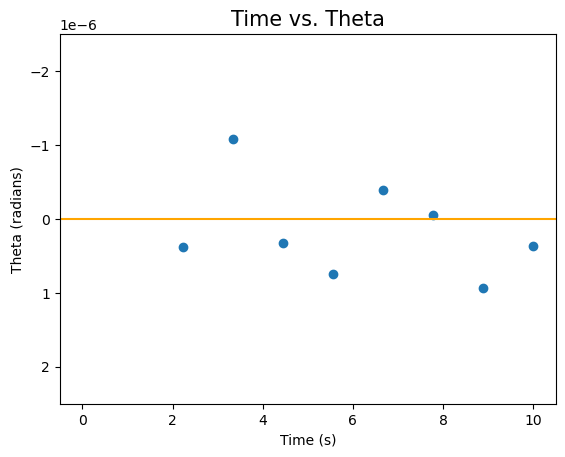

In [23]:
plt.scatter(time_vals, theta_vals)
plt.ylim(0.0000025,-0.0000025) # Because the initial theta is so huge...? And also because the numerical thetas found are tiny
plt.axhline(y=0, color='orange') # Confused; horizontal line at x=0 can't exist, assuming it meant y=0
plt.xlabel('Time (s)')
plt.ylabel('Theta (radians)')
plt.title('Time vs. Theta', fontsize=15)

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [25]:
print(f"The numerical period is {T_numerical:.3f}")

The numerical period is 2.222


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [27]:
# The approximation and result are pretty similar! They're both around 2, so it's looking good.

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [29]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [31]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [33]:
df = pd.read_csv(url)

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [35]:
df_country = df[df['location'] == 'United States']
df_country

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
403451,USA,North America,United States,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,-1914.9,-3.09,-3.09,-5.700091
403452,USA,North America,United States,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
403453,USA,North America,United States,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
403454,USA,North America,United States,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
403455,USA,North America,United States,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405120,USA,North America,United States,2024-07-31,103436829.0,NaN,NaN,1192546.0,0.0,88.429,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
405121,USA,North America,United States,2024-08-01,103436829.0,NaN,NaN,1192546.0,0.0,88.429,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
405122,USA,North America,United States,2024-08-02,103436829.0,NaN,NaN,1192546.0,0.0,88.429,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN
405123,USA,North America,United States,2024-08-03,103436829.0,NaN,NaN,1192546.0,0.0,88.429,...,24.6,NaN,2.77,78.86,0.926,338289856,NaN,NaN,NaN,NaN


From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [38]:
df_country = df_country[['date', 'total_cases']].dropna(axis=1)
df_country['days since start'] = range(len(df_country)) # I really like this trick 
df_country

,date,total_cases,days since start
403451,2020-01-05,0.0,0
403452,2020-01-06,0.0,1
403453,2020-01-07,0.0,2
403454,2020-01-08,0.0,3
403455,2020-01-09,0.0,4
...,...,...,...
405120,2024-07-31,103436829.0,1669
405121,2024-08-01,103436829.0,1670
405122,2024-08-02,103436829.0,1671
405123,2024-08-03,103436829.0,1672


Print the first few rows of your `df_country` dataframe.

In [40]:
df_country.head()

,date,total_cases,days since start
403451,2020-01-05,0.0,0
403452,2020-01-06,0.0,1
403453,2020-01-07,0.0,2
403454,2020-01-08,0.0,3
403455,2020-01-09,0.0,4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [42]:
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [44]:
def exponential_growth(t,c_0,r):
    return c_0 * np.exp(r*t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [46]:
days = np.array(df_country['days since start'].iloc[:30])
cases = np.array(df_country['total_cases'].iloc[:30])

days, cases

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 7., 7., 7., 7., 7., 7., 7., 9., 9.]))

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [48]:
popt, cov = curve_fit(exponential_growth, days, cases, p0 = [1,0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [50]:
C0_fit = popt[0]
r_fit = popt[1]

C0_fit, r_fit

(0.12389531182089004, 0.15384246977544797)

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [52]:
print(f'C0 = {C0_fit:.1f}, r = {r_fit:.3f}')

C0 = 0.1, r = 0.154


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [54]:
future_days = np.arange(0,60)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [56]:
predicted_cases = exponential_growth(future_days,C0_fit, r_fit)

**Scatter** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

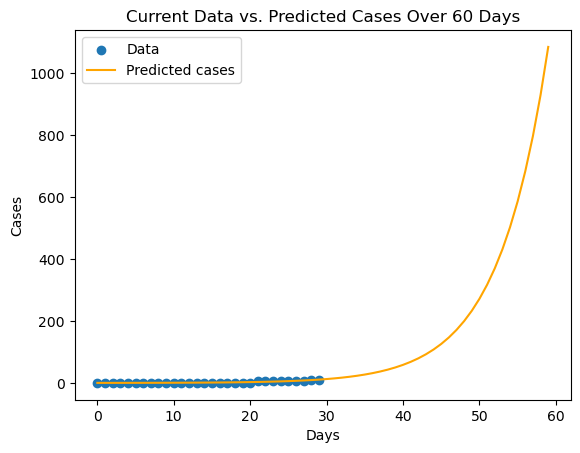

In [58]:
plt.scatter(days, cases, label='Data')
plt.plot(future_days, predicted_cases, color='orange', label='Predicted cases')
plt.xlabel('Days')
plt.ylabel('Cases')
plt.title('Current Data vs. Predicted Cases Over 60 Days')

plt.legend()

#plt.show

How well does your exponential model fit the actual COVID-19 data? 

In [60]:
# It fits incredibly well, I'm curious to see what the residuals look like.

Make another plot but this time to **90 days**.

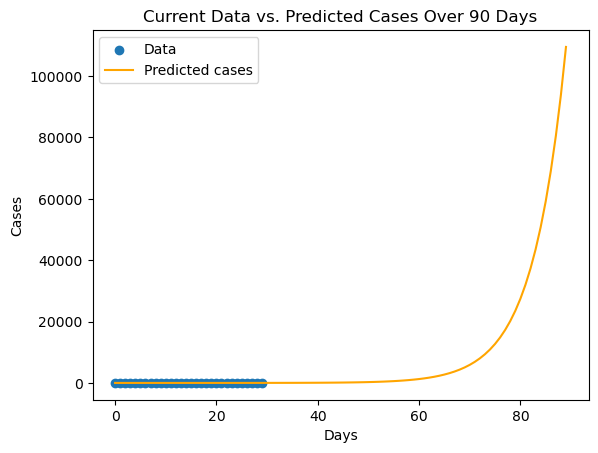

In [62]:
predicted_cases_2 = exponential_growth(np.arange(0,90), C0_fit, r_fit)

plt.scatter(days, cases, label='Data')
plt.plot(np.arange(0,90), predicted_cases_2, color='orange', label='Predicted cases')

plt.title('Current Data vs. Predicted Cases Over 90 Days')
plt.xlabel('Days')
plt.ylabel('Cases')

plt.legend()

# plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [67]:
print(predicted_cases_2[86]) # That's a lot of cases

69018.79040491724


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

<Axes: xlabel='alcohol', ylabel='total'>

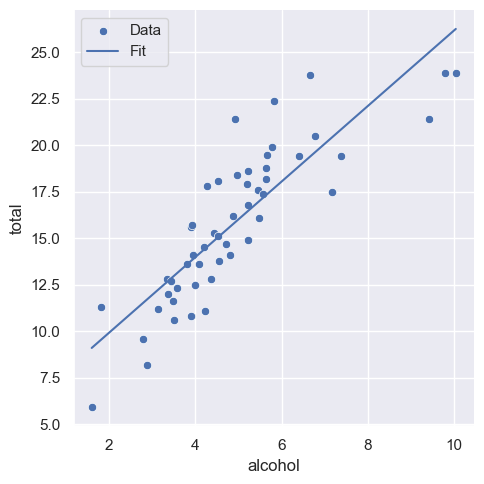

In [119]:
import seaborn as sns

sns.set_theme()

crashes = pd.read_csv('car_crashes.csv') # For some reason I couldn't get sns.load_dataset() to work for me
drunkdriving = crashes[['alcohol', 'total']]

# Trying to see if I can make a linear regression

def linear(x, m, c):
    return m*x + c

alcohol = crashes['alcohol']
total = crashes['total']

popt, cov = curve_fit(linear, alcohol, total, p0=[1,0])
m = popt[0]
c = popt[1]

#sns.relplot(
#    data = drunkdriving,
#    x="alcohol", y="total",
#)

# Using a different seaborn thing because I got confused with .relplot()

sns.scatterplot(x=alcohol, y=total, label='Data')
sns.lineplot(x=alcohol, y=linear(alcohol, m, c), label='Fit')

# Yay it worked!

On it's own branch, submit this notebook to Gradescope! 